# Brazil Labor Market Dashboard
## PNAD Continua 2023-2025

Interactive visualizations of Brazil's labor market and income inequality,
built from PNAD Continua microdata (IBGE) with survey-weighted estimates.

**Data source:** IBGE, PNAD Continua quarterly microdata, 2023Q1-2025Q4  
**Methodology:** Weighted estimates via R survey package (svyglm, svyby)  
**Author:** Teresa De Bastiani - Senior Market Research Analyst

In [53]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

BLUE   = '#2E86AB'
RED    = '#E24B4A'
ORANGE = '#F18F01'
SOFT   = '#B0C4DE'
DARK   = '#2C3E50'

BASE_LAYOUT = dict(
    font_family      = 'Arial',
    font_color       = DARK,
    paper_bgcolor    = 'white',
    plot_bgcolor     = '#F5F5F5',
    title_font_size  = 15,
    title_font_color = DARK,
    legend = dict(orientation='h', yanchor='bottom', y=-0.25),
    margin = dict(l=60, r=40, t=70, b=60),
    hoverlabel = dict(bgcolor='white', font_size=12),
)

EDU_ORDER     = ['No schooling','Primary incomplete','Primary complete','Secondary','Higher education']
AGE_ORDER     = ['14-24','25-34','35-44','45-54','55+']
DECILE_ORDER  = [f'D{i}' for i in range(1, 11)]

print('Setup complete.')

Setup complete.


In [54]:
DATA = 'tableau_export/'

emp_region    = pd.read_csv(DATA + '01a_employment_by_region.csv',    sep=';', decimal=',')
inc_edu       = pd.read_csv(DATA + '01b_income_by_education.csv',     sep=';', decimal=',')
inc_job       = pd.read_csv(DATA + '01c_income_by_job_type.csv',      sep=';', decimal=',')
emp_age       = pd.read_csv(DATA + '01d_employment_by_age.csv',       sep=';', decimal=',')
nat_income    = pd.read_csv(DATA + '01e_national_mean_income.csv',    sep=';', decimal=',')
gender_region = pd.read_csv(DATA + '02a_income_gender_region.csv',    sep=';', decimal=',')
race_gender   = pd.read_csv(DATA + '02b_income_race_gender.csv',      sep=';', decimal=',')
edu_gender    = pd.read_csv(DATA + '02c_income_education_gender.csv', sep=';', decimal=',')
gender_gap    = pd.read_csv(DATA + '02d_gender_gap_region.csv',       sep=';', decimal=',')
deciles       = pd.read_csv(DATA + '03_income_deciles.csv',           sep=';', decimal=',')

print('Data loaded.')
print(f'Periods: {sorted(nat_income["period"].unique())}')

Data loaded.
Periods: ['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']


---
# Part 1 - Labor Market Overview
### 1.1 National mean income trend

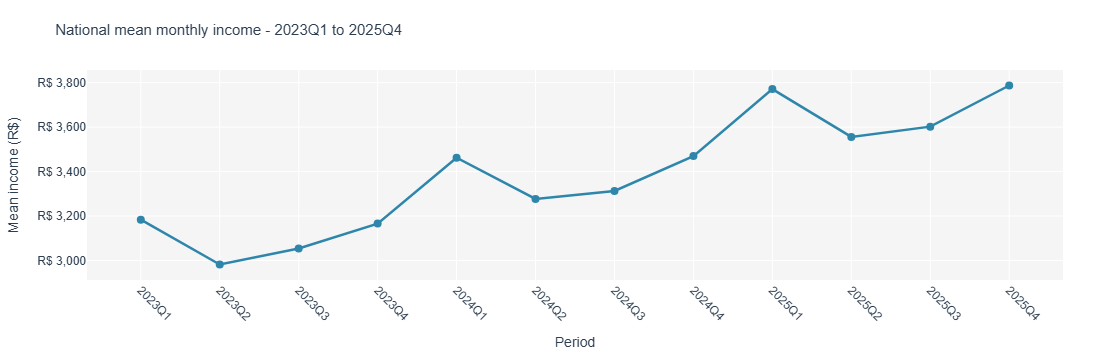

In [56]:
fig1 = px.line(
    nat_income.sort_values('period'),
    x='period', y='mean_income', markers=True,
    title='National mean monthly income - 2023Q1 to 2025Q4',
    labels={'period': 'Period', 'mean_income': 'Mean income (R$)'},
    color_discrete_sequence=[BLUE],
)
fig1.update_traces(line_width=2.5, marker_size=8,
    hovertemplate='<b>%{x}</b><br>Mean income: R$ %{y:,.0f}<extra></extra>')
fig1.update_layout(**BASE_LAYOUT)
fig1.update_xaxes(tickangle=45)
fig1.update_yaxes(tickprefix='R$ ', tickformat=',.0f')
fig1.show()

### 1.2 Employment rate by macro-region (average)

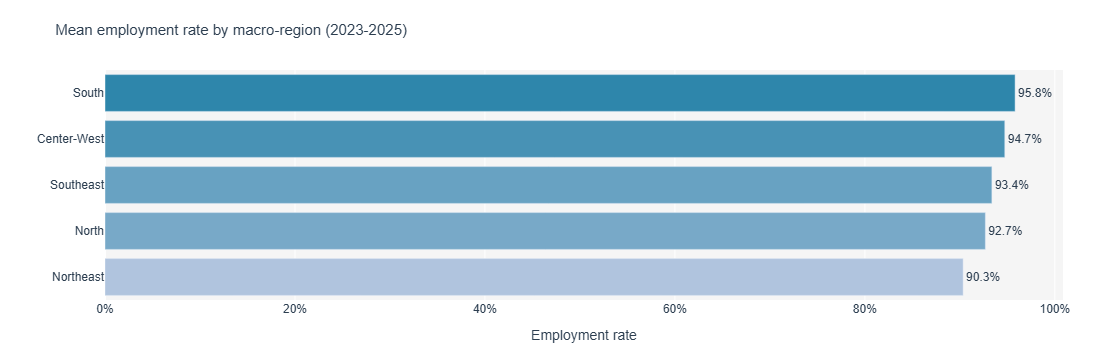

In [58]:
unemp = (
    emp_region
    .groupby('macro_region', as_index=False)['employment_rate']
    .mean()
    .rename(columns={'employment_rate': 'unemp_rate'})
    .sort_values('unemp_rate')
)
fig2 = px.bar(
    unemp, x='unemp_rate', y='macro_region', orientation='h',
    title='Mean employment rate by macro-region (2023-2025)',
    labels={'unemp_rate': 'Employment rate', 'macro_region': ''},
    color='unemp_rate', color_continuous_scale=[SOFT, BLUE],
    text=unemp['unemp_rate'].apply(lambda x: f'{x*100:.1f}%'),
)
fig2.update_traces(textposition='outside',
    hovertemplate='<b>%{y}</b><br>Employment rate: %{x:.1%}<extra></extra>')
fig2.update_layout(**BASE_LAYOUT, coloraxis_showscale=False, xaxis_tickformat='.0%')
fig2.show()

### 1.3 Employment rate by macro-region over time

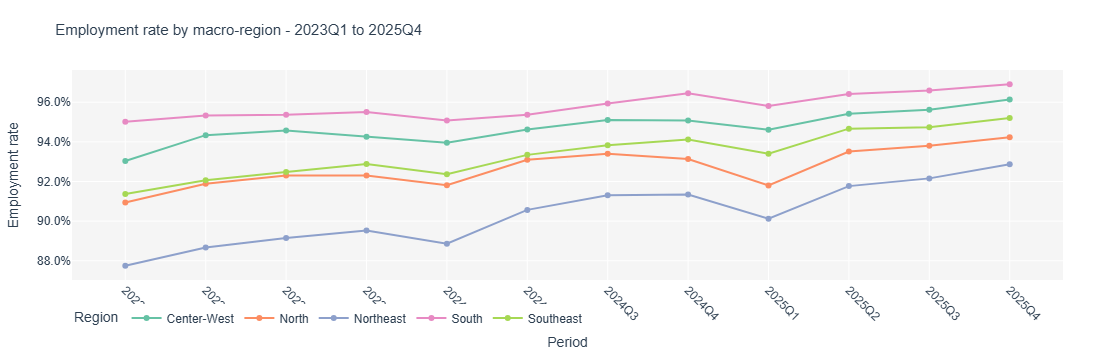

In [60]:
unemp_trend = emp_region.rename(columns={'employment_rate': 'unemp_rate'}).sort_values('period')
fig3 = px.line(
    unemp_trend, x='period', y='unemp_rate', color='macro_region', markers=True,
    title='Employment rate by macro-region - 2023Q1 to 2025Q4',
    labels={'period': 'Period', 'unemp_rate': 'Employment rate', 'macro_region': 'Region'},
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig3.update_traces(line_width=2, marker_size=6,
    hovertemplate='<b>%{fullData.name}</b><br>%{x}: %{y:.1%}<extra></extra>')
fig3.update_layout(**BASE_LAYOUT)
fig3.update_xaxes(tickangle=45)
fig3.update_yaxes(tickformat='.1%')
fig3.show()

### 1.4 Mean income by job type

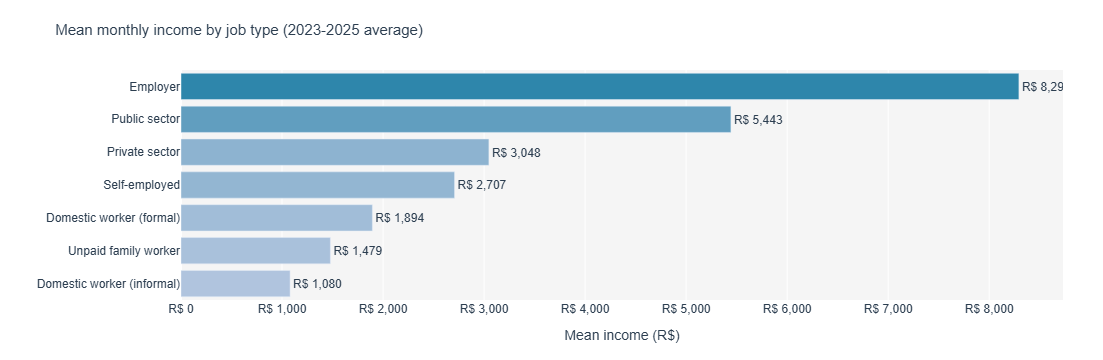

In [62]:
job_avg = (
    inc_job.groupby('job_type', as_index=False)['mean_income']
    .mean().sort_values('mean_income')
)
fig4 = px.bar(
    job_avg, x='mean_income', y='job_type', orientation='h',
    title='Mean monthly income by job type (2023-2025 average)',
    labels={'mean_income': 'Mean income (R$)', 'job_type': ''},
    color='mean_income', color_continuous_scale=[SOFT, BLUE],
    text=job_avg['mean_income'].apply(lambda x: f'R$ {x:,.0f}'),
)
fig4.update_traces(textposition='outside',
    hovertemplate='<b>%{y}</b><br>Mean income: R$ %{x:,.0f}<extra></extra>')
fig4.update_layout(**BASE_LAYOUT, coloraxis_showscale=False,
                   xaxis_tickprefix='R$ ', xaxis_tickformat=',.0f')
fig4.show()

### 1.5 Employment rate by age group

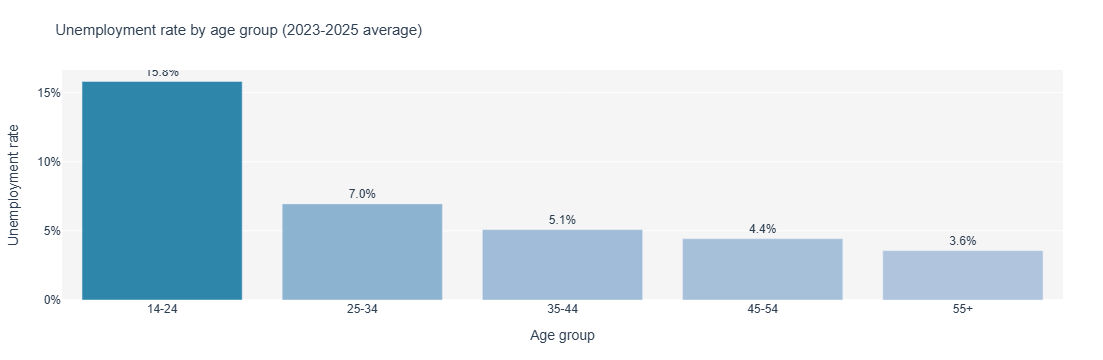

In [64]:
age_avg = (
    emp_age.groupby('age_group', as_index=False)['unemployment_rate']
    .mean().rename(columns={'unemployment_rate': 'emp_rate'})
)
age_avg['age_group'] = pd.Categorical(age_avg['age_group'], categories=AGE_ORDER, ordered=True)
age_avg = age_avg.sort_values('age_group')

fig5 = px.bar(
    age_avg, x='age_group', y='emp_rate',
    title='Unemployment rate by age group (2023-2025 average)',
    labels={'age_group': 'Age group', 'emp_rate': 'Unemployment rate'},
    color='emp_rate', color_continuous_scale=[SOFT, BLUE],
    text=age_avg['emp_rate'].apply(lambda x: f'{x*100:.1f}%'),
)
fig5.update_traces(textposition='outside',
    hovertemplate='<b>%{x}</b><br>Unemployment rate: %{y:.1%}<extra></extra>')
fig5.update_layout(**BASE_LAYOUT, coloraxis_showscale=False, yaxis_tickformat='.0%')
fig5.show()

---
# Part 2 - Income Inequality
### 2.1 Mean income by gender and macro-region

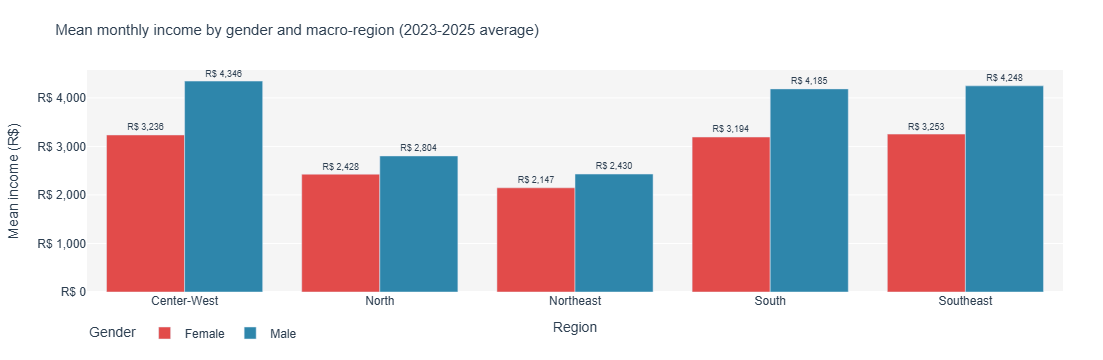

In [66]:
gr_avg = gender_region.groupby(['macro_region','gender'], as_index=False)['mean_income'].mean()
fig6 = px.bar(
    gr_avg, x='macro_region', y='mean_income', color='gender', barmode='group',
    title='Mean monthly income by gender and macro-region (2023-2025 average)',
    labels={'macro_region': 'Region', 'mean_income': 'Mean income (R$)', 'gender': 'Gender'},
    color_discrete_map={'Male': BLUE, 'Female': RED},
    text=gr_avg['mean_income'].apply(lambda x: f'R$ {x:,.0f}'),
)
fig6.update_traces(textposition='outside', textfont_size=9,
    hovertemplate='<b>%{x} - %{fullData.name}</b><br>Mean income: R$ %{y:,.0f}<extra></extra>')
fig6.update_layout(**BASE_LAYOUT, yaxis_tickprefix='R$ ', yaxis_tickformat=',.0f')
fig6.show()

### 2.2 Gender income gap by macro-region over time

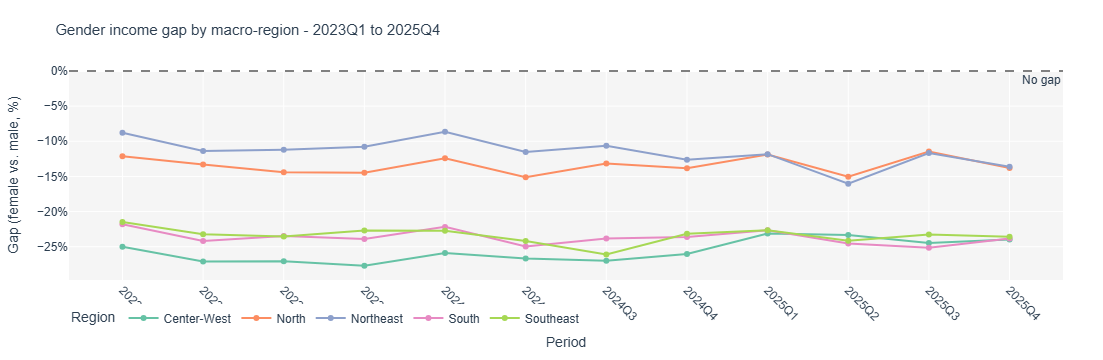

In [68]:
fig7 = px.line(
    gender_gap.sort_values('period'),
    x='period', y='gender_gap_pct', color='macro_region', markers=True,
    title='Gender income gap by macro-region - 2023Q1 to 2025Q4',
    labels={'period': 'Period', 'gender_gap_pct': 'Gap (female vs. male, %)', 'macro_region': 'Region'},
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig7.add_hline(y=0, line_dash='dash', line_color='grey',
               annotation_text='No gap', annotation_position='bottom right')
fig7.update_traces(line_width=2, marker_size=6,
    hovertemplate='<b>%{fullData.name}</b><br>%{x}: %{y:.1f}%<extra></extra>')
fig7.update_layout(**BASE_LAYOUT)
fig7.update_xaxes(tickangle=45)
fig7.update_yaxes(ticksuffix='%')
fig7.show()

### 2.3 Mean income by race and gender

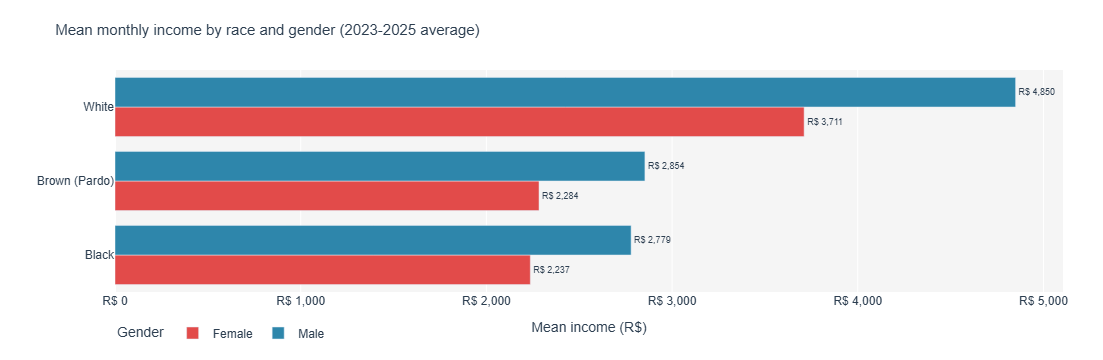

In [70]:
rg_avg = (
    race_gender.groupby(['race','gender'], as_index=False)['mean_income']
    .mean().sort_values('mean_income')
)
fig8 = px.bar(
    rg_avg, x='mean_income', y='race', color='gender', barmode='group', orientation='h',
    title='Mean monthly income by race and gender (2023-2025 average)',
    labels={'mean_income': 'Mean income (R$)', 'race': '', 'gender': 'Gender'},
    color_discrete_map={'Male': BLUE, 'Female': RED},
    text=rg_avg['mean_income'].apply(lambda x: f'R$ {x:,.0f}'),
)
fig8.update_traces(textposition='outside', textfont_size=9,
    hovertemplate='<b>%{y} - %{fullData.name}</b><br>Mean income: R$ %{x:,.0f}<extra></extra>')
fig8.update_layout(**BASE_LAYOUT, xaxis_tickprefix='R$ ', xaxis_tickformat=',.0f')
fig8.show()

### 2.4 Mean income by education and gender

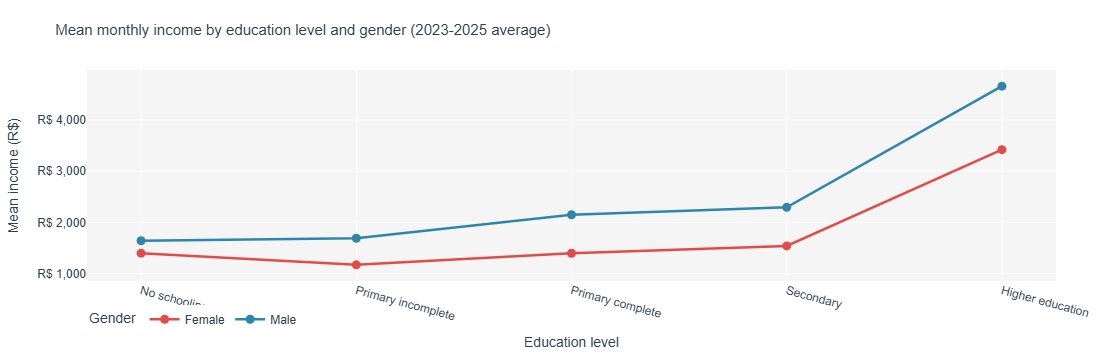

In [72]:
eg_avg = edu_gender.groupby(['education','gender'], as_index=False)['mean_income'].mean()
eg_avg['education'] = pd.Categorical(eg_avg['education'], categories=EDU_ORDER, ordered=True)
eg_avg = eg_avg.sort_values('education')

fig9 = px.line(
    eg_avg, x='education', y='mean_income', color='gender', markers=True,
    title='Mean monthly income by education level and gender (2023-2025 average)',
    labels={'education': 'Education level', 'mean_income': 'Mean income (R$)', 'gender': 'Gender'},
    color_discrete_map={'Male': BLUE, 'Female': RED},
)
fig9.update_traces(line_width=2.5, marker_size=9,
    hovertemplate='<b>%{fullData.name} - %{x}</b><br>Mean income: R$ %{y:,.0f}<extra></extra>')
fig9.update_layout(**BASE_LAYOUT)
fig9.update_yaxes(tickprefix='R$ ', tickformat=',.0f')
fig9.update_xaxes(tickangle=15)
fig9.show()

### 2.5 Income share by decile

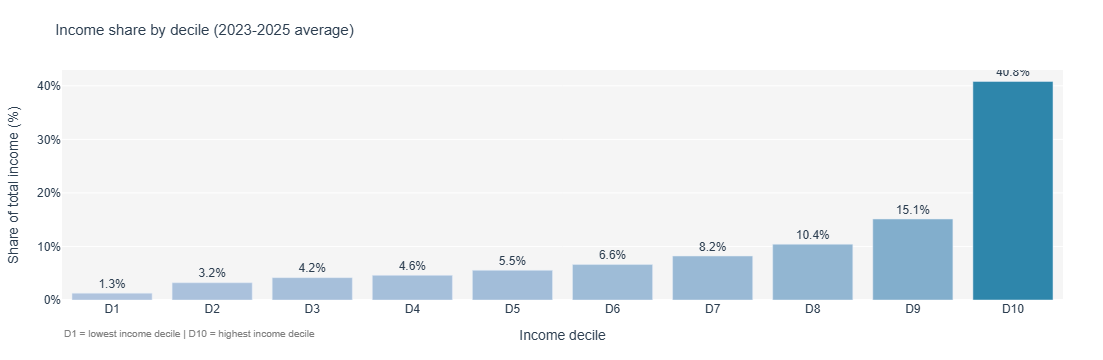

In [74]:
dec_avg = deciles.groupby('decile', as_index=False)['income_share_pct'].mean()
dec_avg['decile'] = pd.Categorical(dec_avg['decile'], categories=DECILE_ORDER, ordered=True)
dec_avg = dec_avg.sort_values('decile')

fig10 = px.bar(
    dec_avg, x='decile', y='income_share_pct',
    title='Income share by decile (2023-2025 average)',
    labels={'decile': 'Income decile', 'income_share_pct': 'Share of total income (%)'},
    color='income_share_pct', color_continuous_scale=[SOFT, BLUE],
    text=dec_avg['income_share_pct'].apply(lambda x: f'{x:.1f}%'),
)
fig10.update_traces(textposition='outside',
    hovertemplate='<b>%{x}</b><br>Income share: %{y:.1f}%<extra></extra>')
fig10.update_layout(**BASE_LAYOUT, coloraxis_showscale=False, yaxis_ticksuffix='%')
fig10.add_annotation(
    text='D1 = lowest income decile | D10 = highest income decile',
    xref='paper', yref='paper', x=0, y=-0.18,
    showarrow=False, font=dict(size=10, color='grey')
)
fig10.show()

---
## Export to HTML

In [76]:
figures = [
    (fig1,  1), (fig2,  1), (fig3,  1), (fig4,  1), (fig5,  1),
    (fig6,  2), (fig7,  2), (fig8,  2), (fig9,  2), (fig10, 2),
]

parts = {
    1: 'Part 1 - Labor Market Overview',
    2: 'Part 2 - Income Inequality',
}

html = []
html.append("""<!DOCTYPE html>
<html lang='en'><head><meta charset='UTF-8'>
<title>Brazil Labor Market Dashboard | PNAD Continua 2023-2025</title>
<style>
body   { font-family: Arial, sans-serif; background:#f9f9f9; margin:0; padding:20px 40px; color:#2C3E50; }
h1     { font-size:24px; margin-bottom:4px; }
h2     { font-size:18px; color:#2E86AB; margin-top:48px; border-bottom:2px solid #2E86AB; padding-bottom:6px; }
p.sub  { color:grey; font-size:13px; margin-top:2px; }
.chart { background:white; border-radius:8px; padding:16px; margin-bottom:24px; box-shadow:0 1px 4px rgba(0,0,0,0.08); }
footer { margin-top:40px; font-size:11px; color:grey; text-align:center; padding-bottom:20px; }
</style></head><body>
<h1>Brazil Labor Market Dashboard</h1>
<p class='sub'>PNAD Continua 2023Q1-2025Q4 | Survey-weighted estimates | Author: Teresa De Bastiani</p>
""")

current_part = 0
for i, (fig, part) in enumerate(figures):
    if part != current_part:
        current_part = part
        html.append(f'<h2>{parts[part]}</h2>')
    js = 'cdn' if i == 0 else False
    html.append(f'<div class="chart">{pio.to_html(fig, full_html=False, include_plotlyjs=js)}</div>')

html.append("""<footer>Source: IBGE, PNAD Continua. Weighted estimates via R survey package.
Analysis by Teresa De Bastiani.</footer></body></html>""")

with open('labor_market_dashboard.html', 'w', encoding='utf-8') as f:
    f.write('\n'.join(html))

print('Exported: labor_market_dashboard.html')

Exported: labor_market_dashboard.html
